# Reflector Experiments
### When Should a Language Model Trust Itself?

This notebook is structured into **three sequential experiments**:

| # | Experiment | Goal |
|---|-----------|------|
| 1 | **Baseline** | Measure raw model accuracy + uncertainty signal distributions |
| 2 | **Oracle Retry Reflection** | Does prompting the model again (when wrong) help? Upper-bound of reflection. |
| 3 | **When to Reflect** | Can entropy/margin predict *whether* the model is wrong, before we know the gold label? |

> **Run order**: Each experiment saves results to disk. Later experiments load from those saved files, so you don't need to re-run inference.

---

## Setup & Imports

In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1" "accelerate" "transformers" "sentencepiece" "safetensors" "scikit-learn"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 112.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import ast
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.calibration import calibration_curve

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm import tqdm

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

RESULTS_DIR = Path("reflector_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## Model Loading

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    quantization_config=quant_config,
    trust_remote_code=True,
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-3B-Instruct


## Shared Utilities
These helpers are used across all three experiments.

In [ ]:
# ─────────────────────────────────────────────
# Label normalisation
# ─────────────────────────────────────────────
def normalize_label(text: str) -> str:
    text = str(text).strip().upper()
    match = re.search(r"\b([A-Z])\b", text)
    if match:
        return match.group(1)
    if text and text[0].isalpha():
        return text[0]
    return text


# ─────────────────────────────────────────────
# Prompt building
# ─────────────────────────────────────────────
def build_system_prompt(valid_labels: list) -> str:
    label_list = ", ".join(valid_labels)
    return (
        "You are a multiple-choice question answering system. "
        "Read the question and options carefully. "
        f"Return only the final answer label, one of {label_list}. "
        "Do not explain your reasoning."
    )


def build_messages(question: str, options: dict) -> list:
    option_lines = [f"{label}. {text}" for label, text in options.items()]
    valid_labels = list(options.keys())
    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        "Answer with only the label."
    )
    return [
        {"role": "system", "content": build_system_prompt(valid_labels)},
        {"role": "user", "content": user_prompt},
    ]


def build_retry_messages(question: str, options: dict, prev_label: str) -> list:
    """
    Retry prompt: tells the model it was wrong and asks it to try again.
    Deliberately avoids revealing the correct answer (no gold-label leak).
    """
    option_lines = [f"{label}. {text}" for label, text in options.items()]
    valid_labels = list(options.keys())
    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        "Answer with only the label."
    )
    return [
        {"role": "system", "content": build_system_prompt(valid_labels)},
        {"role": "user",      "content": user_prompt},
        {"role": "assistant", "content": prev_label},
        {"role": "user",      "content": (
            f"Your answer '{prev_label}' is incorrect. "
            "Please reconsider and provide a different answer label."
        )},
    ]


def build_prompt_text(messages: list) -> str:
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


# ─────────────────────────────────────────────
# Token ID helpers
# ─────────────────────────────────────────────
def get_label_token_ids(label: str) -> list:
    """Return all single-token IDs for a label (bare and space-prefixed)."""
    token_ids = []
    for cand in [label, f" {label}"]:
        ids = tokenizer(cand, add_special_tokens=False)["input_ids"]
        if len(ids) == 1:
            token_ids.append(ids[0])
    token_ids = list(dict.fromkeys(token_ids))
    if not token_ids:
        raise ValueError(f"Label '{label}' has no single-token encoding.")
    return token_ids


# ─────────────────────────────────────────────
# Core inference function
# ─────────────────────────────────────────────
def infer(messages: list, options: dict) -> dict:
    """
    Single inference call.

    Args:
        messages : chat messages built by build_messages() or build_retry_messages()
        options  : dict of {label: text}, e.g. {'A': 'foo', 'B': 'bar'}
                   Passed explicitly so we never have to re-parse the prompt.
    """
    option_labels = list(options.keys())

    prompt_text = build_prompt_text(messages)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        gen_out = model.generate(
            **inputs,
            max_new_tokens=1,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    seq = gen_out.sequences[0]
    generated_ids = seq[prompt_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    generated_label = normalize_label(generated_text)

    # Full vocab distribution at the answer position
    step_scores = gen_out.scores[0][0]
    probs_vocab = torch.softmax(step_scores, dim=-1)
    log_probs_vocab = torch.log_softmax(step_scores, dim=-1)
    entropy_vocab = float(-(probs_vocab * torch.log(probs_vocab + 1e-12)).sum().item())

    # Score each option label from the next-token distribution
    label_scores = {}
    for label in option_labels:
        cand_ids = get_label_token_ids(label)
        cand_lps = torch.tensor(
            [log_probs_vocab[tid].item() for tid in cand_ids], dtype=torch.float32
        )
        # logsumexp combines 'A' and ' A' token variants cleanly
        label_scores[label] = torch.logsumexp(cand_lps, dim=0).item()

    label_logprob_tensor = torch.tensor(
        [label_scores[l] for l in option_labels], dtype=torch.float32
    )
    label_probs_tensor = torch.softmax(label_logprob_tensor, dim=0)
    label_prob_dict = {
        label: float(label_probs_tensor[i].item())
        for i, label in enumerate(option_labels)
    }

    sorted_labels = sorted(label_prob_dict.items(), key=lambda x: x[1], reverse=True)
    top1_label, top1_prob = sorted_labels[0]
    top2_label, top2_prob = sorted_labels[1] if len(sorted_labels) > 1 else (None, None)
    margin = float(top1_prob - top2_prob) if top2_prob is not None else None
    entropy_labels = float(
        -(label_probs_tensor * torch.log(label_probs_tensor + 1e-12)).sum().item()
    )

    return {
        "generated_label": generated_label,
        "predicted_by_probs": top1_label,
        "label_probs": label_prob_dict,
        "label_scores": label_scores,
        "top1_prob": top1_prob,
        "top2_label": top2_label,
        "top2_prob": top2_prob,
        "margin": margin,
        "entropy_over_labels": entropy_labels,
        "entropy_over_vocab": entropy_vocab,
    }

print("Utilities loaded.")

Utilities loaded.


## Load Dataset

In [ ]:
df = pd.read_csv("/content/combined_dataset.csv")
df["choice_labels"] = df["choice_labels"].apply(ast.literal_eval)
df["choice_texts"]  = df["choice_texts"].apply(ast.literal_eval)

print(f"Dataset shape: {df.shape}")
print(df["source"].value_counts())

Dataset shape: (1500, 13)
source
MMLU        250
AQUA-RAT    250
ReClor      250
MedQA       250
ARC-Easy    250
SciQ        250
Name: count, dtype: int64


---
# Experiment 1 — Baseline

**Goal**: Measure raw model accuracy and uncertainty signal distributions, with no reflection.

**What we collect per question**:
- Predicted label (greedy + by option-prob argmax)
- `top1_prob`, `top2_prob`, `margin` (top1 − top2 over option letters)
- `entropy_over_labels` (Shannon entropy over 4/5 option probs)
- `entropy_over_vocab` (Shannon entropy over full vocabulary — higher signal of confusion)

**Outputs saved**: `reflector_results/baseline.jsonl`, `reflector_results/baseline_summary.csv`

In [ ]:
BASELINE_JSONL = RESULTS_DIR / "baseline.jsonl"
BASELINE_CSV   = RESULTS_DIR / "baseline_summary.csv"

# ── Resume from checkpoint if partial run exists ──────────────────────────────
already_done = set()
if BASELINE_JSONL.exists():
    with open(BASELINE_JSONL) as f:
        for line in f:
            try:
                already_done.add(json.loads(line)["row_id"])
            except Exception:
                pass
    print(f"Resuming: {len(already_done)} rows already completed.")

if BASELINE_CSV.exists() and len(already_done) == len(df):
    print(f"Baseline fully complete. Loading from {BASELINE_CSV}...")
    baseline_df = pd.read_csv(BASELINE_CSV)
else:
    summary_rows = []

    # Reload already-saved rows so the final df is complete
    if BASELINE_JSONL.exists():
        with open(BASELINE_JSONL) as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    summary_rows.append({k: v for k, v in rec.items()
                                         if k not in ("label_probs", "label_scores")})
                except Exception:
                    pass

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Baseline"):
        if int(idx) in already_done:
            continue

        question = row["question"]
        options  = dict(zip(row["choice_labels"], row["choice_texts"]))
        gold     = normalize_label(str(row["gold_label"]))
        source   = row.get("source", "unknown")

        messages = build_messages(question, options)
        out = infer(messages, options)

        pred_gen   = normalize_label(out["generated_label"])
        pred_probs = normalize_label(out["predicted_by_probs"])

        record = {
            "row_id":              int(idx),
            "source":              source,
            "gold_label":          gold,
            "pred_generated":      pred_gen,
            "pred_by_probs":       pred_probs,
            "correct_generated":   int(pred_gen   == gold),
            "correct_by_probs":    int(pred_probs  == gold),
            "top1_prob":           out["top1_prob"],
            "top2_prob":           out["top2_prob"],
            "margin":              out["margin"],
            "entropy_over_labels": out["entropy_over_labels"],
            "entropy_over_vocab":  out["entropy_over_vocab"],
            "label_probs":         json.dumps(out["label_probs"]),
            "label_scores":        json.dumps(out["label_scores"]),
        }

        with open(BASELINE_JSONL, "a") as f:
            f.write(json.dumps(record) + "\n")

        summary_rows.append({k: v for k, v in record.items()
                              if k not in ("label_probs", "label_scores")})

    baseline_df = pd.DataFrame(summary_rows).sort_values("row_id").reset_index(drop=True)
    baseline_df.to_csv(BASELINE_CSV, index=False)
    print(f"Saved to {BASELINE_CSV}")

print(baseline_df.shape)
print(baseline_df.head(3))

Resuming: 1133 rows already completed.


Baseline: 100%|██████████| 1500/1500 [00:46<00:00, 32.53it/s]

Saved to reflector_results/baseline_summary.csv
(1500, 12)
   row_id source gold_label pred_generated pred_by_probs  correct_generated  \
0       0   MMLU          B              B             B                  1   
1       1   MMLU          D              A             A                  0   
2       2   MMLU          D              A             A                  0   

   correct_by_probs  top1_prob  top2_prob    margin  entropy_over_labels  \
0                 1   0.977947   0.013460  0.964486             0.125337   
1                 0   0.766824   0.233173  0.533652             0.543123   
2                 0   0.991511   0.008477  0.983034             0.049041   

   entropy_over_vocab  
0            0.155259  
1            0.543127  
2            0.049047  


### 1a — Overall and Per-Source Accuracy

Overall accuracy — greedy decode : 0.651
Overall accuracy — prob argmax   : 0.651

          correct_generated  correct_by_probs
source                                       
AQUA-RAT              0.300             0.300
ARC-Easy              0.924             0.924
MMLU                  0.800             0.800
MedQA                 0.476             0.476
ReClor                0.464             0.464
SciQ                  0.940             0.940


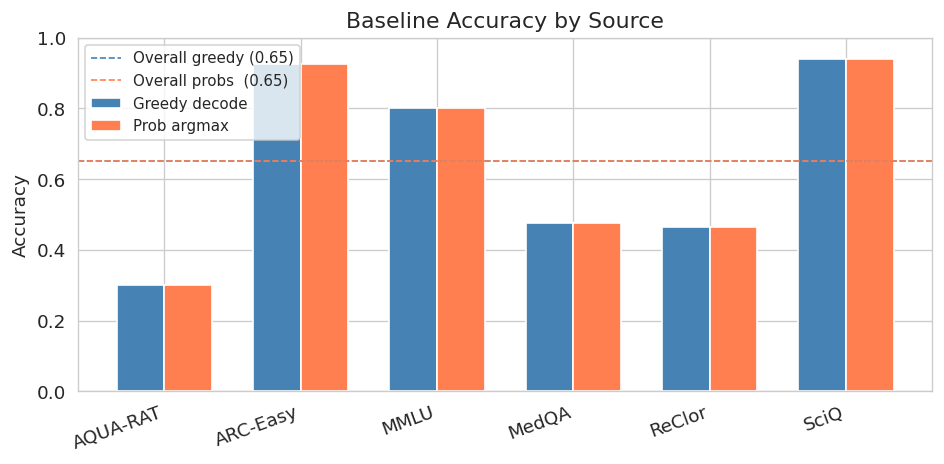

In [ ]:
# ── Overall ───────────────────────────────────────────────────────────────────
acc_gen   = baseline_df["correct_generated"].mean()
acc_probs = baseline_df["correct_by_probs"].mean()
print(f"Overall accuracy — greedy decode : {acc_gen:.3f}")
print(f"Overall accuracy — prob argmax   : {acc_probs:.3f}")
print()

# ── Per source ────────────────────────────────────────────────────────────────
per_source = baseline_df.groupby("source")[["correct_generated", "correct_by_probs"]].mean()
print(per_source.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(per_source))
width = 0.35
ax.bar([i - width/2 for i in x], per_source["correct_generated"],  width, label="Greedy decode", color="steelblue")
ax.bar([i + width/2 for i in x], per_source["correct_by_probs"],   width, label="Prob argmax",   color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(per_source.index, rotation=20, ha="right")
ax.axhline(acc_gen,   color="steelblue", linestyle="--", linewidth=1, label=f"Overall greedy ({acc_gen:.2f})")
ax.axhline(acc_probs, color="coral",     linestyle="--", linewidth=1, label=f"Overall probs  ({acc_probs:.2f})")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Baseline Accuracy by Source")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_accuracy_per_source.png", dpi=150)
plt.show()

### 1b — Uncertainty Signal Distributions (Correct vs Wrong)

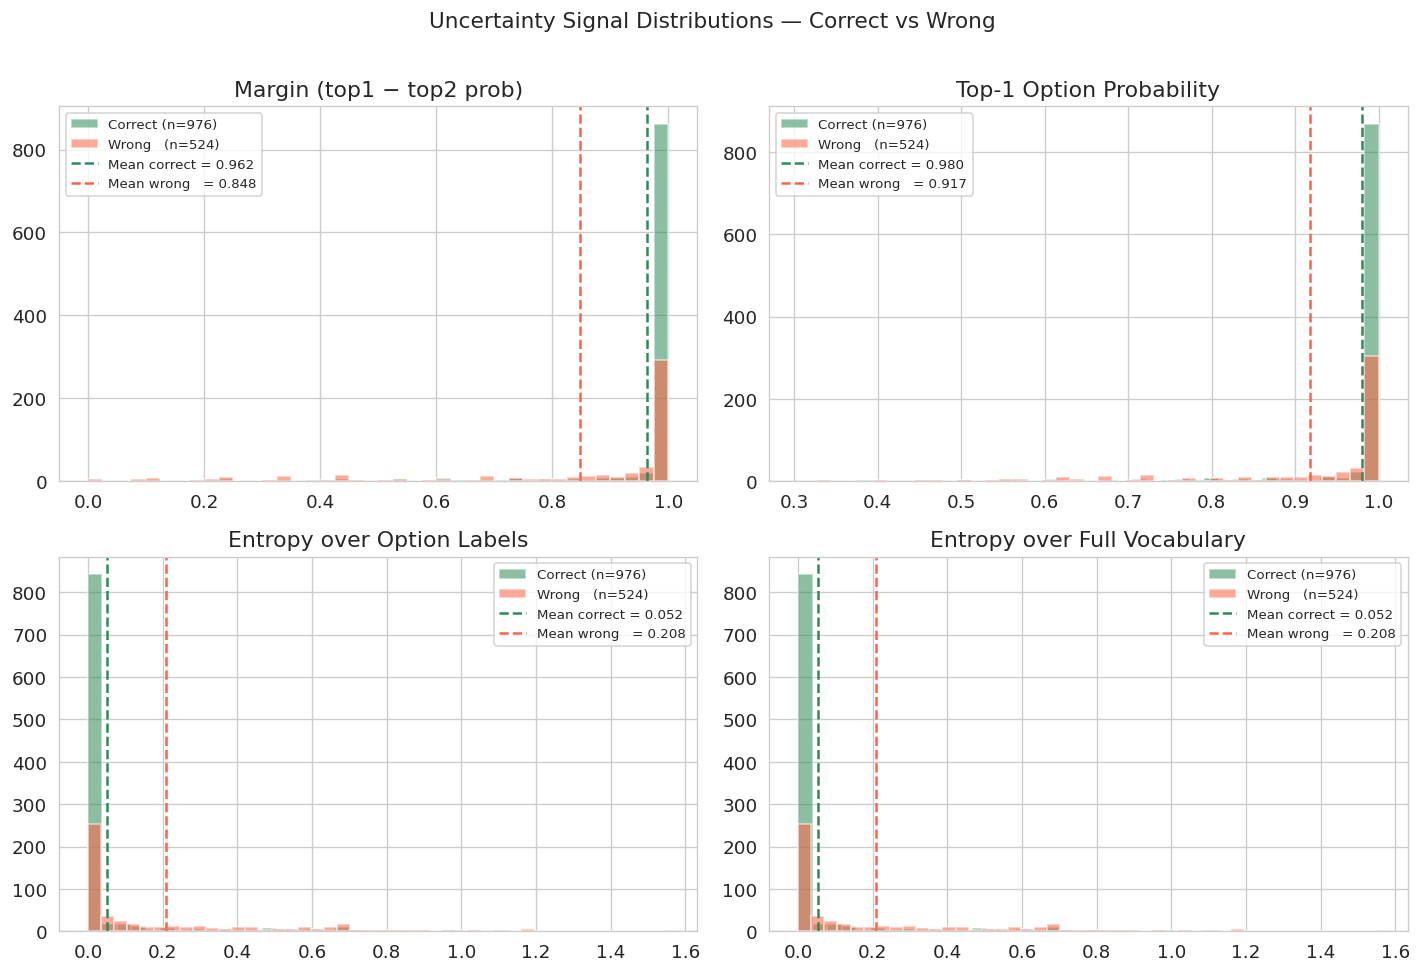


Mean values per signal:
  Margin (top1 − top2 prob)           correct=0.9624  wrong=0.8481
  Top-1 Option Probability            correct=0.9797  wrong=0.9174
  Entropy over Option Labels          correct=0.0521  wrong=0.2084
  Entropy over Full Vocabulary        correct=0.0523  wrong=0.2084


In [ ]:
correct = baseline_df[baseline_df["correct_by_probs"] == 1]
wrong   = baseline_df[baseline_df["correct_by_probs"] == 0]

signals = {
    "margin":              ("Margin (top1 − top2 prob)",    True),
    "top1_prob":           ("Top-1 Option Probability",     True),
    "entropy_over_labels": ("Entropy over Option Labels",   False),
    "entropy_over_vocab":  ("Entropy over Full Vocabulary", False),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, (title, higher_is_confident)) in zip(axes, signals.items()):
    ax.hist(correct[col].dropna(), bins=40, alpha=0.55, color="seagreen",  label=f"Correct (n={len(correct)})")
    ax.hist(wrong[col].dropna(),   bins=40, alpha=0.55, color="tomato",    label=f"Wrong   (n={len(wrong)})")
    m_c = correct[col].mean()
    m_w = wrong[col].mean()
    ax.axvline(m_c, color="seagreen", linestyle="--", linewidth=1.5, label=f"Mean correct = {m_c:.3f}")
    ax.axvline(m_w, color="tomato",   linestyle="--", linewidth=1.5, label=f"Mean wrong   = {m_w:.3f}")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Uncertainty Signal Distributions — Correct vs Wrong", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_signal_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMean values per signal:")
for col, (title, _) in signals.items():
    print(f"  {title:<35} correct={correct[col].mean():.4f}  wrong={wrong[col].mean():.4f}")

### 1c — Reliability Diagram (Calibration)

A well-calibrated model should have accuracy ≈ confidence. This plot shows how much Qwen's top-1 option probability actually correlates with correctness.

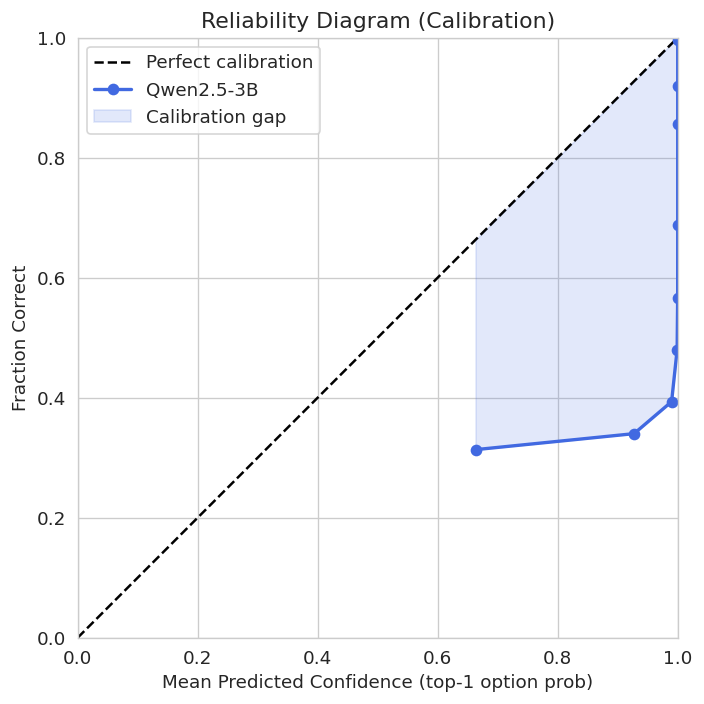

Expected Calibration Error (ECE): 0.3086


In [ ]:
n_bins = 10
fraction_pos, mean_pred = calibration_curve(
    baseline_df["correct_by_probs"],
    baseline_df["top1_prob"],
    n_bins=n_bins,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_pred, fraction_pos, "o-", color="royalblue", linewidth=2, markersize=6, label="Qwen2.5-3B")
ax.fill_between(mean_pred, fraction_pos, mean_pred,
                alpha=0.15, color="royalblue", label="Calibration gap")
ax.set_xlabel("Mean Predicted Confidence (top-1 option prob)")
ax.set_ylabel("Fraction Correct")
ax.set_title("Reliability Diagram (Calibration)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_calibration.png", dpi=150)
plt.show()

# ECE
bins = np.linspace(0, 1, n_bins + 1)
ece = 0.0
n = len(baseline_df)
for i in range(n_bins):
    mask = (baseline_df["top1_prob"] >= bins[i]) & (baseline_df["top1_prob"] < bins[i+1])
    if mask.sum() == 0:
        continue
    acc_bin  = baseline_df.loc[mask, "correct_by_probs"].mean()
    conf_bin = baseline_df.loc[mask, "top1_prob"].mean()
    ece += (mask.sum() / n) * abs(acc_bin - conf_bin)

print(f"Expected Calibration Error (ECE): {ece:.4f}")

---
# Experiment 2 — Oracle Retry Reflection

**Goal**: When the model is wrong (using ground truth as oracle), retry once with a structured "you were wrong" prompt. Measure:
- How often does reflection recover the correct answer? (Recovery rate)
- Does entropy/margin change on the retry?
- What is the net accuracy gain?

> **Oracle framing note**: We use gold labels to decide *when* to retry. This is an upper bound — it tells us the ceiling potential of reflection as a strategy, before we tackle *when* to reflect in Experiment 3.

**Outputs saved**: `reflector_results/retry_results.csv`

In [ ]:
RETRY_CSV = RESULTS_DIR / "retry_results.csv"

if RETRY_CSV.exists():
    print(f"Retry results already exist at {RETRY_CSV}. Loading...")
    retry_df = pd.read_csv(RETRY_CSV)
else:
    # Only retry questions the model got wrong
    wrong_indices = baseline_df[baseline_df["correct_by_probs"] == 0]["row_id"].tolist()
    print(f"Model was wrong on {len(wrong_indices)} / {len(baseline_df)} questions. Retrying...")

    retry_rows = []

    for idx in tqdm(wrong_indices, desc="Retry"):
        row = df.iloc[idx]
        question = row["question"]
        options  = dict(zip(row["choice_labels"], row["choice_texts"]))
        gold     = normalize_label(str(row["gold_label"]))
        source   = row.get("source", "unknown")

        # Original (baseline) prediction
        orig_pred = normalize_label(baseline_df.loc[baseline_df["row_id"] == idx, "pred_by_probs"].values[0])
        orig_entropy = baseline_df.loc[baseline_df["row_id"] == idx, "entropy_over_labels"].values[0]
        orig_margin  = baseline_df.loc[baseline_df["row_id"] == idx, "margin"].values[0]

        # Retry
        retry_messages = build_retry_messages(question, options, orig_pred)
        retry_out = infer(retry_messages, options)

        retry_pred = normalize_label(retry_out["predicted_by_probs"])
        retry_correct = int(retry_pred == gold)
        changed_answer = int(retry_pred != orig_pred)

        retry_rows.append({
            "row_id":          idx,
            "source":          source,
            "gold_label":      gold,
            "orig_pred":       orig_pred,
            "retry_pred":      retry_pred,
            "retry_correct":   retry_correct,
            "changed_answer":  changed_answer,
            # Uncertainty signals — original
            "orig_entropy":    orig_entropy,
            "orig_margin":     orig_margin,
            # Uncertainty signals — after retry
            "retry_entropy":   retry_out["entropy_over_labels"],
            "retry_margin":    retry_out["margin"],
            "retry_top1_prob": retry_out["top1_prob"],
        })

    retry_df = pd.DataFrame(retry_rows)
    retry_df.to_csv(RETRY_CSV, index=False)
    print(f"Saved to {RETRY_CSV}")

print(retry_df.shape)
print(retry_df.head(3))

Model was wrong on 524 / 1500 questions. Retrying...


Retry: 100%|██████████| 524/524 [01:07<00:00,  7.76it/s]

Saved to reflector_results/retry_results.csv
(524, 12)
   row_id source gold_label orig_pred retry_pred  retry_correct  \
0       1   MMLU          D         A          B              0   
1       2   MMLU          D         A          B              0   
2      12   MMLU          A         C          A              1   

   changed_answer  orig_entropy  orig_margin  retry_entropy  retry_margin  \
0               1      0.543123     0.533652       0.000174      0.999972   
1               1      0.049041     0.983034       0.000895      0.999876   
2               1      0.000039     0.999995       0.001107      0.999803   

   retry_top1_prob  
0         0.999986  
1         0.999922  
2         0.999895  


### 2a — Recovery Rate & Net Accuracy Gain

In [ ]:
n_wrong    = len(retry_df)
n_total    = len(baseline_df)
n_correct  = baseline_df["correct_by_probs"].sum()

recovered  = retry_df["retry_correct"].sum()
changed    = retry_df["changed_answer"].sum()

recovery_rate  = recovered / n_wrong if n_wrong > 0 else 0
change_rate    = changed / n_wrong if n_wrong > 0 else 0

# Of the answers that changed, how many were correct?
changed_to_correct = retry_df[retry_df["changed_answer"] == 1]["retry_correct"].mean()
# Of the answers that did NOT change, how many were correct? (should be 0 since gold != orig_pred always)
unchanged_correct  = retry_df[retry_df["changed_answer"] == 0]["retry_correct"].mean()

baseline_acc  = baseline_df["correct_by_probs"].mean()
post_retry_acc = (n_correct + recovered) / n_total

print("="*55)
print(f"Questions retried (model was wrong): {n_wrong}")
print(f"Answers that changed after retry   : {changed} ({change_rate:.1%})")
print(f"  └─ Of changed answers, correct   : {changed_to_correct:.1%}")
print(f"  └─ Of unchanged answers, correct : {unchanged_correct:.1%}  (gold != orig by construction)")
print(f"Total recovered (now correct)      : {recovered} ({recovery_rate:.1%} of wrong)")
print("-"*55)
print(f"Baseline accuracy    : {baseline_acc:.4f}")
print(f"Post-retry accuracy  : {post_retry_acc:.4f}  (+{post_retry_acc - baseline_acc:.4f})")
print("="*55)

Questions retried (model was wrong): 524
Answers that changed after retry   : 522 (99.6%)
  └─ Of changed answers, correct   : 37.9%
  └─ Of unchanged answers, correct : 0.0%  (gold != orig by construction)
Total recovered (now correct)      : 198 (37.8% of wrong)
-------------------------------------------------------
Baseline accuracy    : 0.6507
Post-retry accuracy  : 0.7827  (+0.1320)


          n_wrong  recovered  changed  recovery_rate  change_rate
source                                                           
AQUA-RAT      175         46      174       0.262857     0.994286
ARC-Easy       19          9       19       0.473684     1.000000
MMLU           50         22       50       0.440000     1.000000
MedQA         131         46      131       0.351145     1.000000
ReClor        134         61      134       0.455224     1.000000
SciQ           15         14       14       0.933333     0.933333


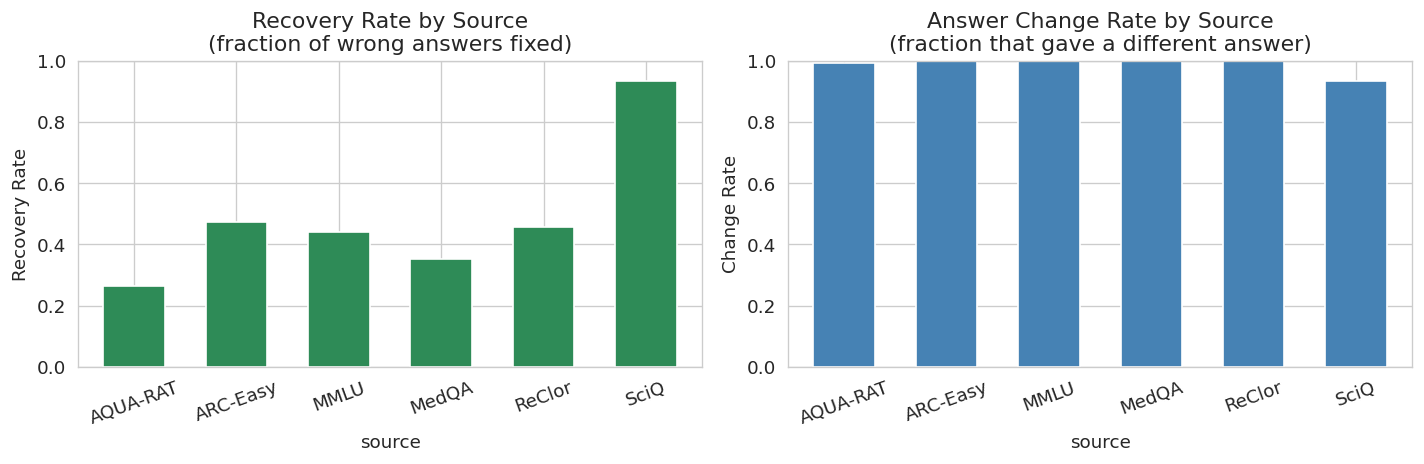

In [ ]:
# ── Recovery rate per source ──────────────────────────────────────────────────
per_source_retry = retry_df.groupby("source").agg(
    n_wrong     =("retry_correct", "count"),
    recovered   =("retry_correct", "sum"),
    changed     =("changed_answer", "sum"),
).assign(
    recovery_rate = lambda d: d["recovered"] / d["n_wrong"],
    change_rate   = lambda d: d["changed"]   / d["n_wrong"],
)
print(per_source_retry.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

per_source_retry["recovery_rate"].plot.bar(ax=axes[0], color="seagreen", width=0.6)
axes[0].set_title("Recovery Rate by Source\n(fraction of wrong answers fixed)")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Recovery Rate")
axes[0].tick_params(axis="x", rotation=20)

per_source_retry["change_rate"].plot.bar(ax=axes[1], color="steelblue", width=0.6)
axes[1].set_title("Answer Change Rate by Source\n(fraction that gave a different answer)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Change Rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "retry_recovery_per_source.png", dpi=150)
plt.show()

### 2b — Does the Retry Reduce Entropy / Increase Margin?

If reflection is *qualitatively* useful, we should see higher confidence (lower entropy, higher margin) on questions that were recovered vs not.

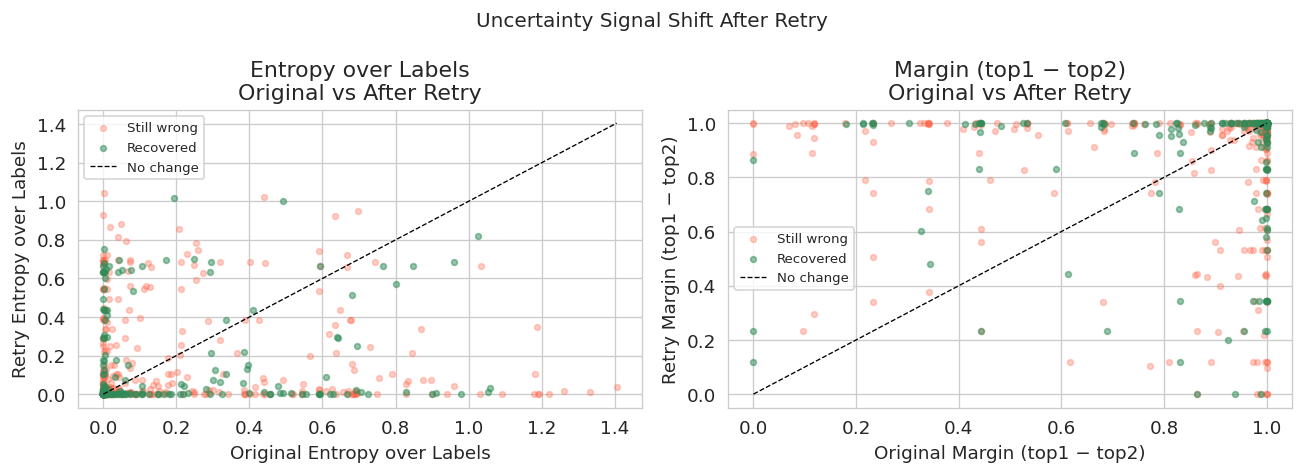


Mean entropy shift (retry − original):
  Recovered : -0.0280
  Still wrong: -0.0391


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (orig_col, retry_col, label) in zip(axes, [
    ("orig_entropy", "retry_entropy", "Entropy over Labels"),
    ("orig_margin",  "retry_margin",  "Margin (top1 − top2)"),
]):
    recovered_mask = retry_df["retry_correct"] == 1
    not_recovered  = retry_df["retry_correct"] == 0

    ax.scatter(
        retry_df.loc[not_recovered,  orig_col],
        retry_df.loc[not_recovered,  retry_col],
        alpha=0.3, s=12, color="tomato",   label="Still wrong"
    )
    ax.scatter(
        retry_df.loc[recovered_mask, orig_col],
        retry_df.loc[recovered_mask, retry_col],
        alpha=0.5, s=12, color="seagreen", label="Recovered"
    )
    mn = min(retry_df[orig_col].min(), retry_df[retry_col].min())
    mx = max(retry_df[orig_col].max(), retry_df[retry_col].max())
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=0.8, label="No change")
    ax.set_xlabel(f"Original {label}")
    ax.set_ylabel(f"Retry {label}")
    ax.set_title(f"{label}\nOriginal vs After Retry")
    ax.legend(fontsize=8)

plt.suptitle("Uncertainty Signal Shift After Retry", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "retry_uncertainty_shift.png", dpi=150)
plt.show()

print("\nMean entropy shift (retry − original):")
print(f"  Recovered : {(retry_df.loc[retry_df['retry_correct']==1,'retry_entropy'] - retry_df.loc[retry_df['retry_correct']==1,'orig_entropy']).mean():.4f}")
print(f"  Still wrong: {(retry_df.loc[retry_df['retry_correct']==0,'retry_entropy'] - retry_df.loc[retry_df['retry_correct']==0,'orig_entropy']).mean():.4f}")

---
# Experiment 3 — When to Reflect

**Goal**: Can we predict *before* looking at the gold label whether the model is wrong — using only the uncertainty signals from the first pass?

We treat this as a **binary classification** problem:
- Label `1` = model is wrong (should trigger reflection)
- Label `0` = model is correct (no need to reflect)

**Signals tested**:
| Signal | Expected direction |
|--------|-------------------|
| `entropy_over_labels` | Higher → more likely wrong |
| `entropy_over_vocab`  | Higher → more likely wrong |
| `margin`              | Lower  → more likely wrong |
| `top1_prob`           | Lower  → more likely wrong |

**Analysis**:
1. ROC AUC for each signal
2. Precision-Recall for each signal
3. Threshold sweep — accuracy vs. fraction of questions reflected
4. Per-source breakdown of signal quality

In [ ]:
# Build the prediction target: 1 = model was wrong = should reflect
target = 1 - baseline_df["correct_by_probs"].values   # 1 = wrong

# Signals (higher value = higher predicted error probability)
signal_configs = {
    "entropy_over_labels": baseline_df["entropy_over_labels"].values,
    "entropy_over_vocab":  baseline_df["entropy_over_vocab"].values,
    "1 - margin":          1 - baseline_df["margin"].values,          # invert so higher = more uncertain
    "1 - top1_prob":       1 - baseline_df["top1_prob"].values,
}

print("ROC AUC and Average Precision for each signal (predicting model error):")
print("-"*60)
auc_results = {}
for name, scores in signal_configs.items():
    auc = roc_auc_score(target, scores)
    ap  = average_precision_score(target, scores)
    auc_results[name] = (auc, ap)
    print(f"  {name:<25}  ROC-AUC={auc:.4f}   Avg-Precision={ap:.4f}")

ROC AUC and Average Precision for each signal (predicting model error):
------------------------------------------------------------
  entropy_over_labels        ROC-AUC=0.8190   Avg-Precision=0.6436
  entropy_over_vocab         ROC-AUC=0.8185   Avg-Precision=0.6428
  1 - margin                 ROC-AUC=0.8183   Avg-Precision=0.6373
  1 - top1_prob              ROC-AUC=0.8186   Avg-Precision=0.6379


### 3a — ROC Curves

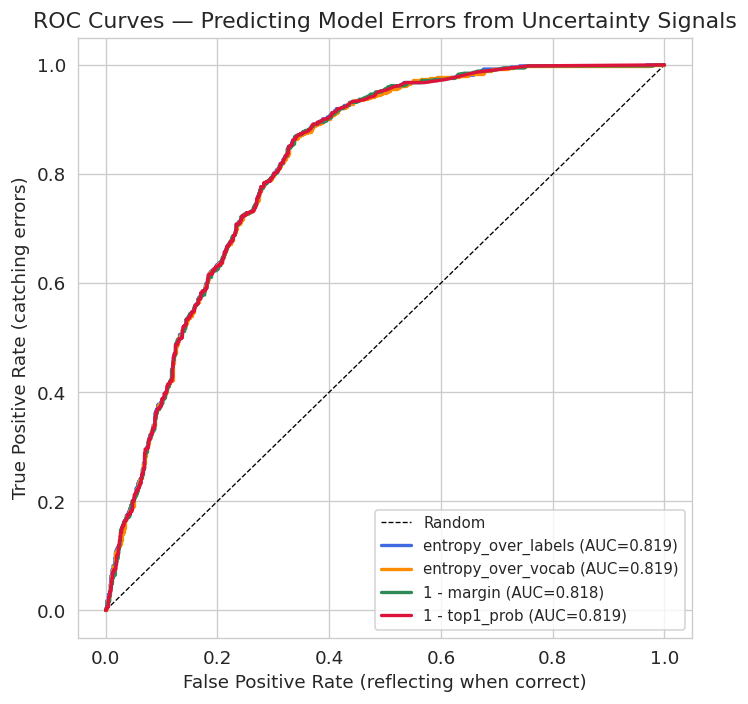

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")

colors = ["royalblue", "darkorange", "seagreen", "crimson"]
for (name, scores), color in zip(signal_configs.items(), colors):
    fpr, tpr, _ = roc_curve(target, scores)
    auc = auc_results[name][0]
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.set_xlabel("False Positive Rate (reflecting when correct)")
ax.set_ylabel("True Positive Rate (catching errors)")
ax.set_title("ROC Curves — Predicting Model Errors from Uncertainty Signals")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_roc.png", dpi=150)
plt.show()

### 3b — Threshold Sweep: Accuracy vs. Reflection Rate

Key insight: if we reflect on a fraction `f` of questions (those with highest uncertainty), what accuracy do we achieve — assuming the reflection recovers errors at the rate observed in Experiment 2?

Empirical recovery rate from Experiment 2: 0.378


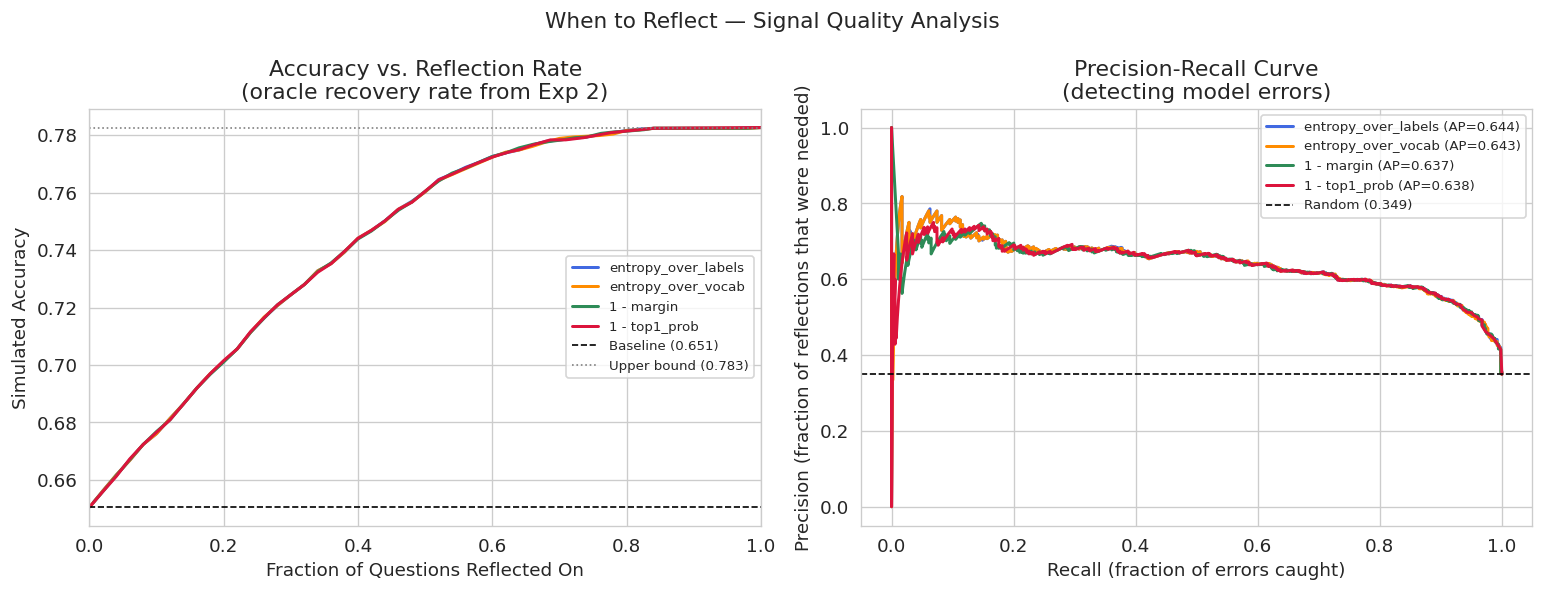

In [ ]:
# Empirical recovery rate from Experiment 2
try:
    recovery_rate_emp = retry_df["retry_correct"].mean()
except NameError:
    recovery_rate_emp = 0.35   # fallback if retry_df not in scope
print(f"Empirical recovery rate from Experiment 2: {recovery_rate_emp:.3f}")

n_total = len(baseline_df)
baseline_acc = baseline_df["correct_by_probs"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, scores), color in zip(signal_configs.items(), colors):
    thresholds = np.percentile(scores, np.arange(0, 101, 2))  # percentile sweep
    reflect_fracs = []
    simulated_accs = []

    for thresh in thresholds:
        reflect_mask = scores >= thresh   # reflect on high-uncertainty questions
        n_reflect = reflect_mask.sum()
        frac = n_reflect / n_total

        # Wrong questions that fall into the reflection set
        wrong_mask = target == 1
        wrong_reflected = (reflect_mask & wrong_mask).sum()

        # Correct questions that fall into the reflection set (wasted reflections)
        correct_reflected = (reflect_mask & ~wrong_mask).sum()

        # Simulated outcome
        n_correct_baseline = (1 - target).sum()
        n_additionally_correct = wrong_reflected * recovery_rate_emp

        # Assume reflecting on already-correct questions doesn't hurt
        simulated_acc = (n_correct_baseline + n_additionally_correct) / n_total

        reflect_fracs.append(frac)
        simulated_accs.append(simulated_acc)

    axes[0].plot(reflect_fracs, simulated_accs, color=color, linewidth=1.8, label=name)

axes[0].axhline(baseline_acc, color="black", linestyle="--", linewidth=1, label=f"Baseline ({baseline_acc:.3f})")
upper_bound = baseline_acc + (1 - baseline_acc) * recovery_rate_emp
axes[0].axhline(upper_bound, color="gray", linestyle=":", linewidth=1, label=f"Upper bound ({upper_bound:.3f})")
axes[0].set_xlabel("Fraction of Questions Reflected On")
axes[0].set_ylabel("Simulated Accuracy")
axes[0].set_title("Accuracy vs. Reflection Rate\n(oracle recovery rate from Exp 2)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1)

# Precision-recall of detecting wrong answers
from sklearn.metrics import precision_recall_curve
for (name, scores), color in zip(signal_configs.items(), colors):
    precision, recall, _ = precision_recall_curve(target, scores)
    ap = auc_results[name][1]
    axes[1].plot(recall, precision, color=color, linewidth=1.8, label=f"{name} (AP={ap:.3f})")

axes[1].axhline(target.mean(), color="black", linestyle="--", linewidth=1,
                label=f"Random ({target.mean():.3f})")
axes[1].set_xlabel("Recall (fraction of errors caught)")
axes[1].set_ylabel("Precision (fraction of reflections that were needed)")
axes[1].set_title("Precision-Recall Curve\n(detecting model errors)")
axes[1].legend(fontsize=8)

plt.suptitle("When to Reflect — Signal Quality Analysis", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

### 3c — Per-Source Signal Quality (AUC Heatmap)

Are some signals better predictors of error for specific question types (e.g., medical vs. logic reasoning)?

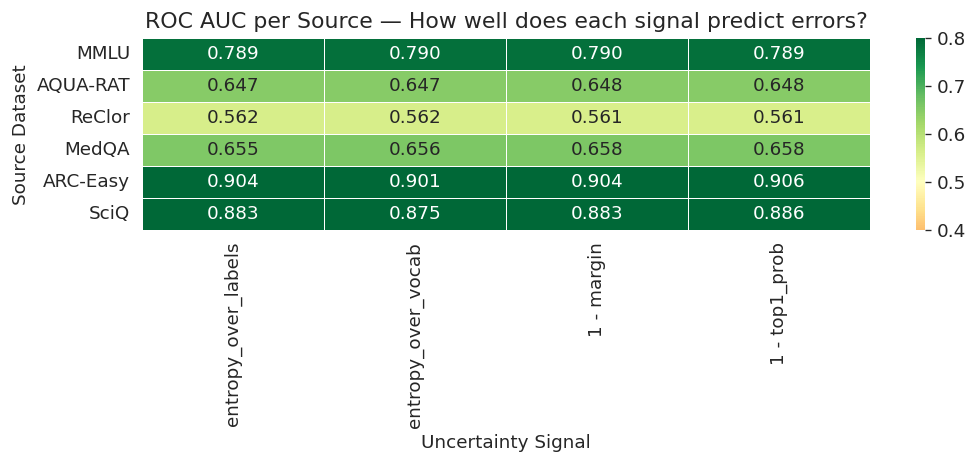

In [ ]:
sources = baseline_df["source"].unique()
signal_names = list(signal_configs.keys())

auc_matrix = pd.DataFrame(index=sources, columns=signal_names, dtype=float)

for source in sources:
    mask = baseline_df["source"] == source
    tgt_src = target[mask]
    if tgt_src.sum() == 0 or tgt_src.sum() == len(tgt_src):
        continue  # can't compute AUC
    for name, scores in signal_configs.items():
        try:
            auc_matrix.loc[source, name] = roc_auc_score(tgt_src, scores[mask])
        except Exception:
            auc_matrix.loc[source, name] = float("nan")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    auc_matrix.astype(float),
    annot=True, fmt=".3f",
    cmap="RdYlGn", center=0.5,
    vmin=0.4, vmax=0.8,
    ax=ax, linewidths=0.5,
)
ax.set_title("ROC AUC per Source — How well does each signal predict errors?")
ax.set_xlabel("Uncertainty Signal")
ax.set_ylabel("Source Dataset")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_auc_heatmap.png", dpi=150)
plt.show()

### 3d — Optimal Threshold Analysis

For each signal, find the threshold that maximises F1 for detecting errors. This is the practical "cut point" you would use to decide when to trigger reflection.

In [ ]:
from sklearn.metrics import f1_score

print(f"{'Signal':<25} {'Best Threshold':>15} {'F1':>8} {'Precision':>11} {'Recall':>9}")
print("-"*72)

for name, scores in signal_configs.items():
    thresholds = np.percentile(scores, np.arange(5, 96, 1))
    best_f1, best_thresh, best_prec, best_rec = 0, None, 0, 0

    for thresh in thresholds:
        preds = (scores >= thresh).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(target, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            from sklearn.metrics import precision_score, recall_score
            best_prec = precision_score(target, preds, zero_division=0)
            best_rec  = recall_score(target, preds, zero_division=0)

    print(f"  {name:<23} {best_thresh:>15.4f} {best_f1:>8.4f} {best_prec:>11.4f} {best_rec:>9.4f}")

Signal                     Best Threshold       F1   Precision    Recall
------------------------------------------------------------------------
  entropy_over_labels              0.0001   0.6933      0.5795    0.8626
  entropy_over_vocab               0.0001   0.6917      0.5782    0.8607
  1 - margin                       0.0000   0.6929      0.5748    0.8721
  1 - top1_prob                    0.0000   0.6927      0.5787    0.8626


### 3e — Confidence Binning: Does Low Confidence Actually Mean Wrong?

Sort by entropy into decile buckets. For each bucket, plot: error rate. If entropy is a good signal, error rate should monotonically increase.

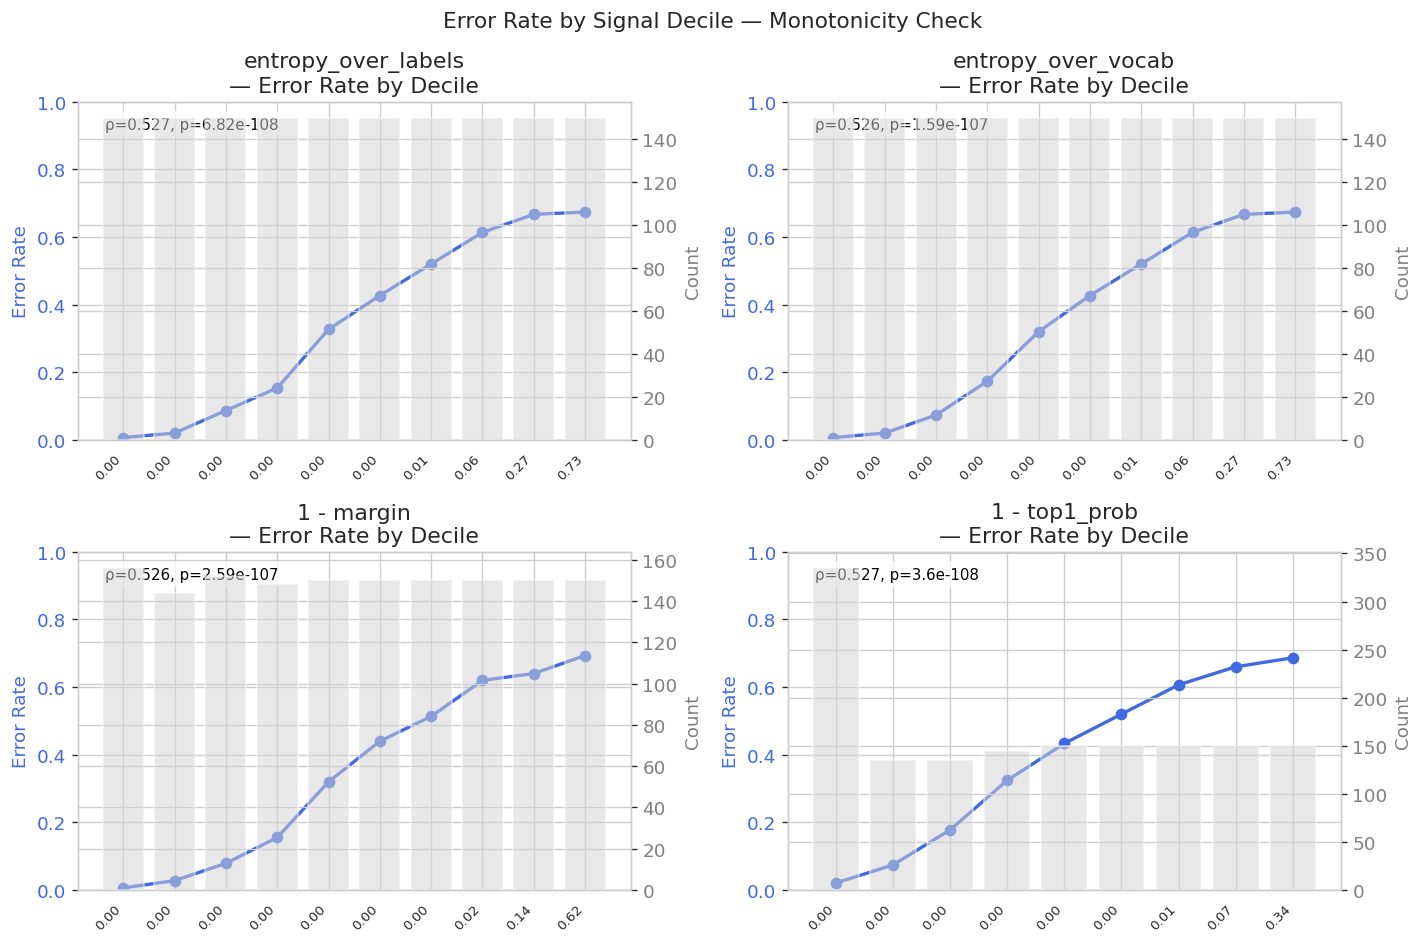

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

n_bins = 10

for ax, (name, scores) in zip(axes, signal_configs.items()):
    bin_labels = pd.qcut(pd.Series(scores), q=n_bins, labels=False, duplicates="drop")
    bin_centers = []
    error_rates = []
    counts = []

    for b in sorted(bin_labels.unique()):
        mask = bin_labels == b
        bin_centers.append(scores[mask].mean())
        error_rates.append(target[mask].mean())
        counts.append(mask.sum())

    ax2 = ax.twinx()
    ax2.bar(range(len(bin_centers)), counts, color="lightgray", alpha=0.5, label="Count")
    ax2.set_ylabel("Count", color="gray")
    ax2.tick_params(axis="y", labelcolor="gray")

    ax.plot(range(len(bin_centers)), error_rates, "o-", color="royalblue", linewidth=2, zorder=5)
    ax.set_xticks(range(len(bin_centers)))
    ax.set_xticklabels([f"{c:.2f}" for c in bin_centers], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Error Rate", color="royalblue")
    ax.tick_params(axis="y", labelcolor="royalblue")
    ax.set_title(f"{name}\n— Error Rate by Decile")
    ax.set_ylim(0, 1)

    # Spearman correlation
    rho, pval = stats.spearmanr(scores, target)
    ax.text(0.05, 0.92, f"ρ={rho:.3f}, p={pval:.3g}", transform=ax.transAxes,
            fontsize=9, color="black", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.suptitle("Error Rate by Signal Decile — Monotonicity Check", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "when_to_reflect_decile_error.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary Dashboard

In [ ]:
print("="*65)
print("  REFLECTOR EXPERIMENTS — SUMMARY")
print("="*65)

# Experiment 1
print("\nExperiment 1 — Baseline")
print(f"  Accuracy (greedy):   {baseline_df['correct_generated'].mean():.4f}")
print(f"  Accuracy (prob-max): {baseline_df['correct_by_probs'].mean():.4f}")
print(f"  ECE:                 {ece:.4f}")

# Experiment 2
print("\nExperiment 2 — Oracle Retry Reflection")
print(f"  Questions retried:   {len(retry_df)}")
print(f"  Recovery rate:       {retry_df['retry_correct'].mean():.4f}")
print(f"  Answer change rate:  {retry_df['changed_answer'].mean():.4f}")
print(f"  Post-retry accuracy: {post_retry_acc:.4f}  (+{post_retry_acc - baseline_acc:.4f})")

# Experiment 3
print("\nExperiment 3 — When to Reflect (ROC AUC for error prediction)")
for name, (auc, ap) in auc_results.items():
    print(f"  {name:<25} AUC={auc:.4f}  AP={ap:.4f}")

print("\nSaved plots:")
for p in sorted(RESULTS_DIR.glob("*.png")):
    print(f"  {p}")
print("="*65)

  REFLECTOR EXPERIMENTS — SUMMARY

Experiment 1 — Baseline
  Accuracy (greedy):   0.6507
  Accuracy (prob-max): 0.6507
  ECE:                 0.3086

Experiment 2 — Oracle Retry Reflection
  Questions retried:   524
  Recovery rate:       0.3779
  Answer change rate:  0.9962
  Post-retry accuracy: 0.7827  (+0.1320)

Experiment 3 — When to Reflect (ROC AUC for error prediction)
  entropy_over_labels       AUC=0.8190  AP=0.6436
  entropy_over_vocab        AUC=0.8185  AP=0.6428
  1 - margin                AUC=0.8183  AP=0.6373
  1 - top1_prob             AUC=0.8186  AP=0.6379

Saved plots:
  reflector_results/baseline_accuracy_per_source.png
  reflector_results/baseline_calibration.png
  reflector_results/baseline_signal_distributions.png
  reflector_results/retry_recovery_per_source.png
  reflector_results/retry_uncertainty_shift.png
  reflector_results/when_to_reflect_auc_heatmap.png
  reflector_results/when_to_reflect_decile_error.png
  reflector_results/when_to_reflect_roc.png
  refle